In [1]:
import pandas as pd
import numpy as np
import sklearn

In [2]:
df_loan = pd.read_csv('/Users/sirawitjudjan/Documents/สมัครงาน/โปรเจคสมัครงาน/Credit risk analysis/loans_full_schema_1.csv')
df_loan = df_loan.dropna()  # Drop rows with missing values

In [3]:
x_col_names = ['log_annual_income', 'debt_to_income', 'delinq_2y', 'num_collections_last_12m', 'num_historical_failed_to_pay', 'num_cc_carrying_balance', 'account_never_delinq_percent', 'tax_liens', 'loan_amount', 'term', 'interest_rate', 'grade', 'total_credit_utilized']
y_col_name = 'loan_status'

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = df_loan[x_col_names].copy()
X = add_constant(X)
vif_df = pd.DataFrame()
vif_df["Feature"] = X.columns
vif_df["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]
print(vif_df[vif_df["Feature"] != "const"].reset_index(drop=True))

                         Feature        VIF
0              log_annual_income   1.939192
1                 debt_to_income   2.001324
2                      delinq_2y   1.218766
3       num_collections_last_12m   1.024169
4   num_historical_failed_to_pay   1.476892
5        num_cc_carrying_balance   1.167912
6   account_never_delinq_percent   1.241408
7                      tax_liens   1.497180
8                    loan_amount   1.573822
9                           term   1.446028
10                 interest_rate  19.583046
11                         grade  19.571409
12         total_credit_utilized   2.167709


In [5]:
x_col_names = ['log_annual_income', 'debt_to_income', 'delinq_2y', 'num_collections_last_12m', 'num_historical_failed_to_pay', 'num_cc_carrying_balance', 'account_never_delinq_percent', 'tax_liens', 'loan_amount', 'term', 'interest_rate', 'total_credit_utilized']


In [6]:
from sklearn.model_selection import train_test_split
X = df_loan[x_col_names]
y = df_loan[y_col_name]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(class_weight='balanced',
    random_state=42,
    max_iter=1000, C=
    0.001)

log_reg.fit(X_train_scaled, y_train)



,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.001
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [14]:
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
y_prob 

array([0.53890481, 0.47550335, 0.52192727, 0.51926715, 0.48221242,
       0.48276332, 0.50998058, 0.52616193, 0.50996684, 0.47981085,
       0.46669161, 0.48970282, 0.47591735, 0.53598933, 0.49263289,
       0.46904872, 0.4969604 , 0.47952489, 0.50012827, 0.49998311,
       0.50966127, 0.50038296, 0.48943342, 0.48451099, 0.48776196,
       0.54987403, 0.50216885, 0.49832331, 0.48652598, 0.48727466,
       0.46826057, 0.49629464, 0.53163593, 0.4805448 , 0.48961097,
       0.49762791, 0.4932291 , 0.50722003, 0.47020271, 0.47378048,
       0.48201011, 0.50730556, 0.47860715, 0.49356346, 0.52272817,
       0.51185192, 0.5042688 , 0.50357337, 0.48856354, 0.47742192,
       0.48471933, 0.47584252, 0.48328668, 0.48536978, 0.50227334,
       0.49784009, 0.47909985, 0.48027949, 0.50397199, 0.4953135 ,
       0.48469185, 0.47880575, 0.48287414, 0.47210131, 0.48261737,
       0.50897756, 0.49457888, 0.47930984, 0.50729809, 0.49654946,
       0.54313932, 0.51718883, 0.48169423, 0.49606117, 0.49868

In [24]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)
precision, recall, thresholds

(array([0.19266055, 0.19444444, 0.19626168, 0.19811321, 0.2       ,
        0.20192308, 0.2038835 , 0.20588235, 0.20792079, 0.21      ,
        0.2020202 , 0.20408163, 0.20618557, 0.20833333, 0.21052632,
        0.21276596, 0.21505376, 0.2173913 , 0.21978022, 0.22222222,
        0.2247191 , 0.22727273, 0.22988506, 0.23255814, 0.23529412,
        0.23809524, 0.24096386, 0.24390244, 0.24691358, 0.25      ,
        0.25316456, 0.25641026, 0.25974026, 0.25      , 0.25333333,
        0.25675676, 0.26027397, 0.26388889, 0.26760563, 0.25714286,
        0.26086957, 0.25      , 0.23880597, 0.24242424, 0.24615385,
        0.25      , 0.25396825, 0.25806452, 0.26229508, 0.26666667,
        0.27118644, 0.27586207, 0.28070175, 0.26785714, 0.27272727,
        0.27777778, 0.28301887, 0.28846154, 0.2745098 , 0.28      ,
        0.28571429, 0.29166667, 0.27659574, 0.2826087 , 0.28888889,
        0.29545455, 0.30232558, 0.30952381, 0.31707317, 0.325     ,
        0.33333333, 0.31578947, 0.2972973 , 0.30

Matplotlib is building the font cache; this may take a moment.


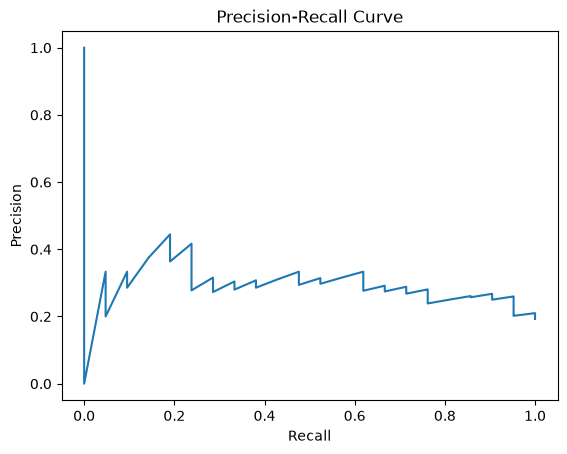

In [29]:
import matplotlib.pyplot as plt

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [30]:
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)

In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6697247706422018


In [32]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[60 28]
 [ 8 13]]
              precision    recall  f1-score   support

           0       0.88      0.68      0.77        88
           1       0.32      0.62      0.42        21

    accuracy                           0.67       109
   macro avg       0.60      0.65      0.59       109
weighted avg       0.77      0.67      0.70       109



In [33]:
from sklearn.metrics import roc_auc_score

y_prob = log_reg.predict_proba(X_test_scaled)[:,1]

auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC =", auc)


ROC-AUC = 0.6818181818181818
